# Worst Case Headway Time Experiments

In [1]:
from typing import Dict, List, Tuple

import copy
import itertools
import pickle

import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from policies import *
from routes import *
from wc_analysis import *
from prob_analysis import *

## Plotting Helpers

In [2]:
def plot_headway(results) -> None:
    fig = go.Figure()
    whitespace = 0.2
    width = (1 - whitespace) / len(results.keys())
    for i, name in enumerate(results.keys()):
        offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width
        for stop_idx in range(len(results[name]['route'])):
            fig.add_trace(go.Bar(
                y=[results[name]['worst_case']['headway'][stop_idx]],
                x=[stop_idx + offset],
                base=[results[name]['best_case']['headway'][stop_idx]],
                width=width,
                opacity=0.5,
                marker={'color': px.colors.qualitative.T10[i]},
                name=name,
                showlegend=True if stop_idx == 0 else False,
            ))
            fig.add_trace(go.Box(
                y=results[name]['simulation']['headway'][stop_idx],
                x=[stop_idx + offset] * len(results[name]['simulation']['headway'][stop_idx]),
                showlegend=False,
                width=width,
                marker={'color':px.colors.qualitative.T10[i]},
            ))

    fig.update_yaxes(
        title_text='Headway Time (min.)',
        #title_standoff=0
    )

    fig.update_layout(
        width=500,
        xaxis=dict(
            tickmode='array',
            tickvals=[j for j in range(len(results[name]['route']))],
            title='Stop #',
            title_standoff=2,
        ), 
        legend=dict(
            xanchor='right',
            x=1.15
        ),
        font_family="Times New Roman, serif",
        #title=dict(text='Per Stop Simulated Headway vs. Theoretical Bound', xanchor="center"),
    )

    fig.show()

In [3]:
def plot_travel(results):
    fig = make_subplots(
        rows=2,
        cols=len(results.keys()),
        column_titles=list(results.keys()),
        row_titles=['Upper Bound', 'Actual'],
        x_title="To Stop #",
        y_title="Worst Case<br>Trave Time From Stop #",
    )

    # Normalize Color Scales
    absolute_max = 0
    absolute_min = 1e6
    for name in results.keys():
        for i in results[name]['worst_case']['travel']:
            absolute_max = max(absolute_max, max(i))
            absolute_min = min(absolute_min, min(i))
        for i in results[name]['simulation']['travel']:
            for j in i:
                absolute_max = max(absolute_max, max(j))
                absolute_min = min(absolute_min, min(j))
    
    # Plot The Thing
    for i, name in enumerate(results.keys()):
        fig.add_trace(
            go.Heatmap(
                z=results[name]['worst_case']['travel'],
                text=results[name]['worst_case']['travel'],
                texttemplate="%{text:.0f}",
                showscale=False,
                zmax=absolute_max,
                zmin=absolute_min,
                #textfont={"size":10}
            ),
            row=1,
            col=i + 1,
        )
    for i, name in enumerate(results.keys()):
        z = [[max(k) for k in j] for j in results[name]['simulation']['travel']]
        fig.add_trace(
            go.Heatmap(
                z=z,
                text=z,
                texttemplate="%{text:.0f}",
                showscale=False,
                zmax=absolute_max,
                zmin=absolute_min,
                #textfont={"size":10}
            ),
            row=2,
            col=i + 1,
        )

    fig.show()

In [18]:
def run_experiment(exp_id: str, routes: Dict, start_times: List[List[float]], t_max: int = 60 * 24 * 7) -> None:
    results = {}
    for name, route in routes.items():
        print(f'Working on {name}...')
        wc_headway, bc_headway = wcht(route_factory(route), start_times, t_max)
        wc_travel = []
        for i in range(len(route)):
            wc_travel.append([])
            for j in range(len(route)):
                wc_travel[i].append(wctt(route_factory(route), start_times, wc_headway, i, j))
        prob_results = simulate(route_factory(route), start_times, t_max, seed=0)
        results[name] = {
            'worst_case': {'headway': wc_headway, 'travel': wc_travel},
            'best_case': {'headway': bc_headway},
            'simulation': prob_results,
            'route': route
        }
        print(results[name]['simulation']['headway'][1])

    plot_headway(results)
    plot_travel(results)


## Fig 1: 1st Stop is Control
Make sure this works before proceeding.


Working on $\pi\texttt{NIL}$...
[10.392672882895184, 8.944585575696907, 8.71572747208518, 11.532467515350335, 8.177846378553502, 9.096575495956937, 12.617269097718106, 12.644562301483571, 10.173202124275209, 4.357849704699706, 3.678555516284088, 9.352924689188853, 13.076606363548152, 7.668351445593066, 7.825638222878416, 8.146229723523213, 12.540868456576316, 4.674515891561496, 12.941522623593059, 4.162983947878095, 11.922583060577168, 4.183968812762795, 5.183991492674636, 13.178782489260735, 3.8183195623848243, 3.0736770910944937, 4.364552767794599, 4.730005564080715, 10.434947250629381, 4.306032665809134, 9.33108150518926, 4.47561775303743, 7.264977402118458, 8.620634920455913, 12.731717125803687, 4.127660407985162, 13.609803561482462, 3.7921634155158515, 4.403044180735255, 14.203923796188663, 4.1850962900126145, 4.539564576461056, 4.3966915634583135, 13.794698760814299, 3.369219428145228, 3.359564956600145, 14.075127291213397, 4.248730337447664, 2.9019376468441984, 18.03271312401869

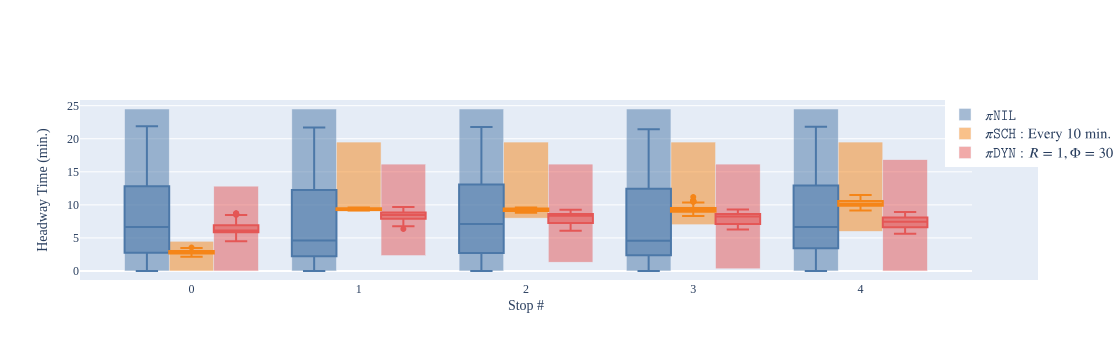

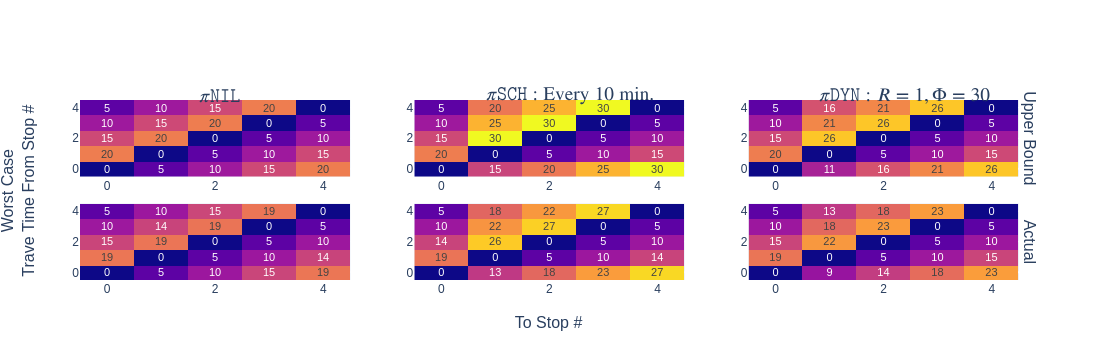

In [22]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0.0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': float('inf')}

routes = {
    r'$\pi\texttt{NIL}$': BASE_ROUTE,
    r'$\pi\texttt{SCH}: \text{Every}\;10\;\text{min.}$': SCHED_ROUTE,
    r'$\pi\texttt{DYN}: R=1, \Phi=30$': RATIO_ROUTE,
}

run_experiment(
    exp_id='exp-base',
    routes=routes,
    start_times=[0, 10, 20],
    t_max=60 * 24 * 7,
)

## Fig. 1: All Points Controlled
We now consider the effects of different policies when applied to every stop along a route.

Setting:
* 10 stops, average completion time uncontrolled: 60 minutes
* 6 vehicles

TODO:
* Outlier headway time on Headway Policy when buses released simultaneously

Working on $\pi\texttt{NIL}$...
[10.392672882895184, 8.944585575696907, 8.71572747208518, 11.532467515350335, 8.177846378553502, 9.096575495956937, 12.617269097718106, 12.644562301483571, 10.173202124275209, 4.357849704699706, 3.678555516284088, 9.352924689188853, 13.076606363548152, 7.668351445593066, 7.825638222878416, 8.146229723523213, 12.540868456576316, 4.674515891561496, 12.941522623593059, 4.162983947878095, 11.922583060577168, 4.183968812762795, 5.183991492674636, 13.178782489260735, 3.8183195623848243, 3.0736770910944937, 4.364552767794599, 4.730005564080715, 10.434947250629381, 4.306032665809134, 9.33108150518926, 4.47561775303743, 7.264977402118458, 8.620634920455913, 12.731717125803687, 4.127660407985162, 13.609803561482462, 3.7921634155158515, 4.403044180735255, 14.203923796188663, 4.1850962900126145, 4.539564576461056, 4.3966915634583135, 13.794698760814299, 3.369219428145228, 3.359564956600145, 14.075127291213397, 4.248730337447664, 2.9019376468441984, 18.03271312401869

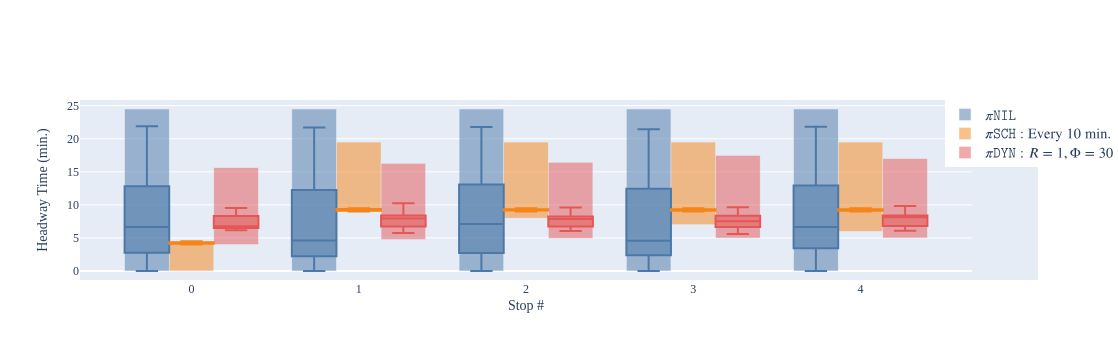

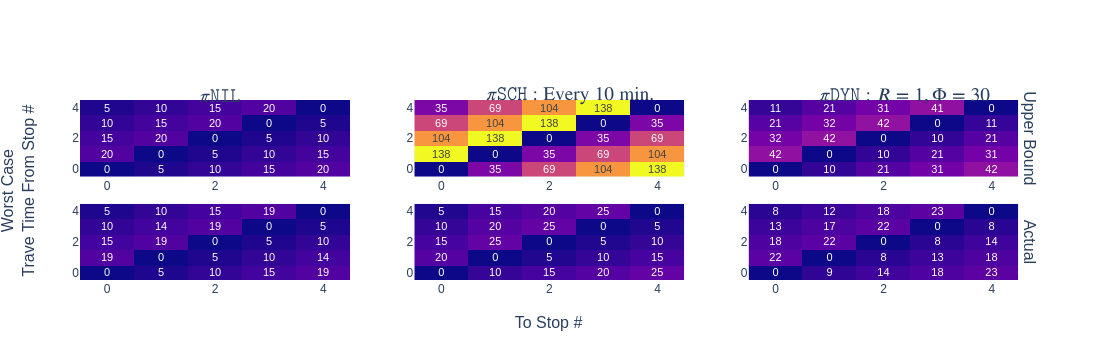

In [21]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
for i in range(N_STOPS):
    SCHED_ROUTE[i]['policy'] = LeakyBucketPolicy
    SCHED_ROUTE[i]['policy_args'] = {'time_delta': 10, 'offset':  5 * i}


# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
for i in range(N_STOPS):
    RATIO_ROUTE[i]['policy'] = RatioDrivenPolicy
    RATIO_ROUTE[i]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': float('inf')}


routes = {
    r'$\pi\texttt{NIL}$': BASE_ROUTE,
    r'$\pi\texttt{SCH}: \text{Every}\;10\;\text{min.}$': SCHED_ROUTE,
    r'$\pi\texttt{DYN}: R=1, \Phi=30$': RATIO_ROUTE,
}

run_experiment(
    exp_id='fig1-policy-comparison',
    routes=routes,
    start_times=[0, 10, 20],
    t_max=60 * 24 * 7,
)

## Fig. 2: Terminal and Midpoint Holding Only
We now consider the effect of applying a policy only at the terminal and at route midpoint.  The setting is the same as the previous figure.

TODO:
* Travel time calculation is incorrect for headway 

Working on $\pi\texttt{SCH}\;@s^{(0)}, s^{(4)}$...
Working on $\pi\texttt{DYN}\;@s^{(0)}, s^{(4)}$...
Working on $\pi\texttt{SCH}\;@s^{(0)},\;\pi\texttt{DYN}\;@s^{(4)}$...


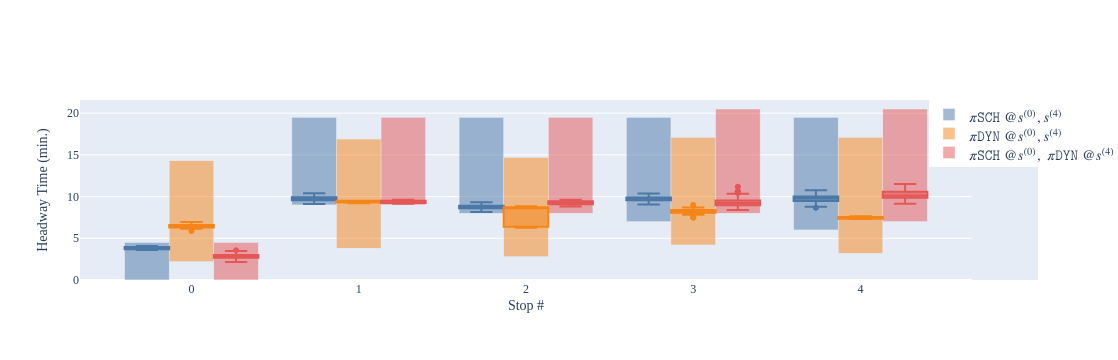

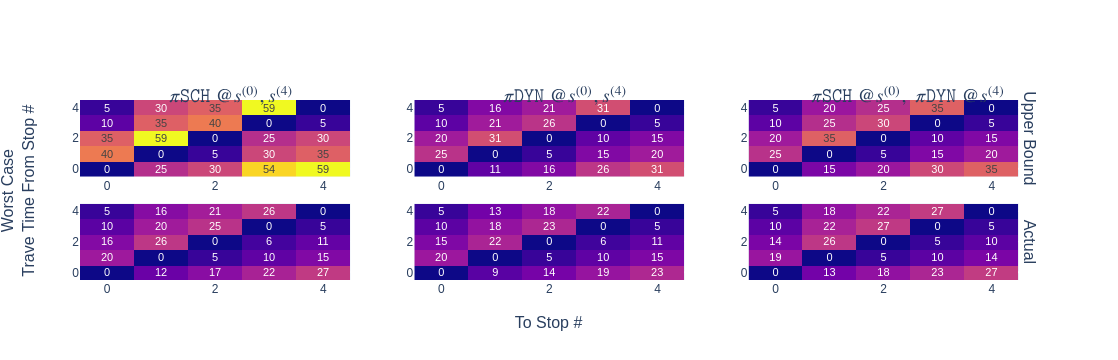

In [7]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}
SCHED_ROUTE[2]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[2]['policy_args'] = {'time_delta': 10, 'offset': 5 * 2}


# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}
RATIO_ROUTE[2]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[2]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}


# Headway Driven Route tries to maintain constant headway regardless of delay
SR_ROUTE = copy.deepcopy(BASE_ROUTE)
SR_ROUTE[0]['policy'] = LeakyBucketPolicy
SR_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}
SR_ROUTE[2]['policy'] = RatioDrivenPolicy
SR_ROUTE[2]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}

# Headway Driven Route tries to maintain constant headway regardless of delay
RS_ROUTE = copy.deepcopy(BASE_ROUTE)
RS_ROUTE[0]['policy'] = RatioDrivenPolicy
RS_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}
RS_ROUTE[2]['policy'] = LeakyBucketPolicy
RS_ROUTE[2]['policy_args'] = {'time_delta': 10, 'offset': 2.5 * 4}

routes = {
    #'Uncontrolled': BASE_ROUTE,
    r'$\pi\texttt{SCH}\;@s^{(0)}, s^{(4)}$': SCHED_ROUTE,
    r'$\pi\texttt{DYN}\;@s^{(0)}, s^{(4)}$': RATIO_ROUTE,
    r'$\pi\texttt{SCH}\;@s^{(0)},\;\pi\texttt{DYN}\;@s^{(4)}$': SR_ROUTE,
    #r'$\pi\texttt{DYN}\;@s^{(0)},\;\pi\texttt{SCH}\;@s^{(4)}$': RS_ROUTE,
}

run_experiment(
    exp_id='fig2-midpoint-holding',
    routes=routes,
    start_times=[0, 10, 20],

    t_max=60 * 24 * 7,
)

## Fig. 3: Stop Parameters
Show the impact number of vehicles has on the same scheduling policy


Working on $\pi\texttt{DYN}, R=1,\Phi=4$...
Working on $\pi\texttt{DYN}, R=0.75,\Phi=4$...
Working on $\pi\texttt{DYN}, R=0.5,\Phi=4$...
Working on $\pi\texttt{DYN}, R=0.25,\Phi=4$...
Working on $\pi\texttt{DYN}, R=1,\Phi=3$...
Working on $\pi\texttt{DYN}, R=1,\Phi=2$...
Working on $\pi\texttt{DYN}, R=1,\Phi=1$...


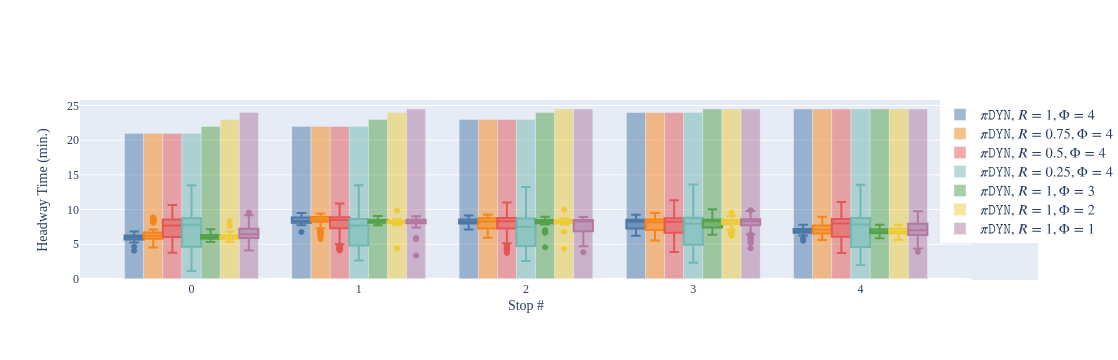

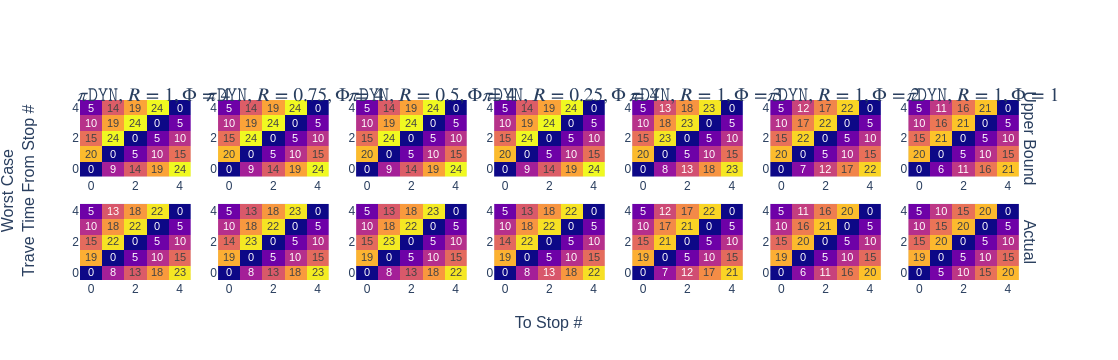

In [8]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(5)
]

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE0 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE0[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE0[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 4}
#RATIO_ROUTE0[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE0[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 4}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE1 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE1[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE1[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': 4}
#RATIO_ROUTE1[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE1[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.75, 'max_holding': 4}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE2 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE2[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE2[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.5, 'max_holding': 4}
#RATIO_ROUTE2[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE2[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.5, 'max_holding': 4}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE3 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE3[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE3[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.25, 'max_holding': 4}
#RATIO_ROUTE3[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE3[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 0.25, 'max_holding': 4}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE4 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE4[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE4[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 3}
#RATIO_ROUTE4[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE4[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 3}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE5 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE5[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE5[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 2}
#RATIO_ROUTE5[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE5[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 2}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE6 = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE6[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE6[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 1}
#RATIO_ROUTE6[4]['policy'] = RatioDrivenPolicy
#RATIO_ROUTE6[4]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': 1}

routes = {
    r'$\pi\texttt{DYN}, R=1,\Phi=4$': RATIO_ROUTE0,
    r'$\pi\texttt{DYN}, R=0.75,\Phi=4$': RATIO_ROUTE1,
    r'$\pi\texttt{DYN}, R=0.5,\Phi=4$': RATIO_ROUTE2,
    r'$\pi\texttt{DYN}, R=0.25,\Phi=4$': RATIO_ROUTE3,
    r'$\pi\texttt{DYN}, R=1,\Phi=3$': RATIO_ROUTE4,
    r'$\pi\texttt{DYN}, R=1,\Phi=2$': RATIO_ROUTE5,
    r'$\pi\texttt{DYN}, R=1,\Phi=1$': RATIO_ROUTE6,
}

run_experiment(
    exp_id='midpoint_holding',
    routes=routes,
    start_times=[0, 10, 20],
    t_max=60 * 24 * 7,
)

## Number of Buses

Working on $\pi\texttt{SCH}\;@s^{(0)}, M=2$...
Working on $\pi\texttt{DYN}\;@s^{(0)}, M=2$...
Working on $\pi\texttt{SCH}\;@s^{(0)}, M=3$...
Working on $\pi\texttt{DYN}\;@s^{(0)}, M=3$...
Working on $\pi\texttt{SCH}\;@s^{(0)}, M=4$...
Working on $\pi\texttt{DYN}\;@s^{(0)}, M=4$...


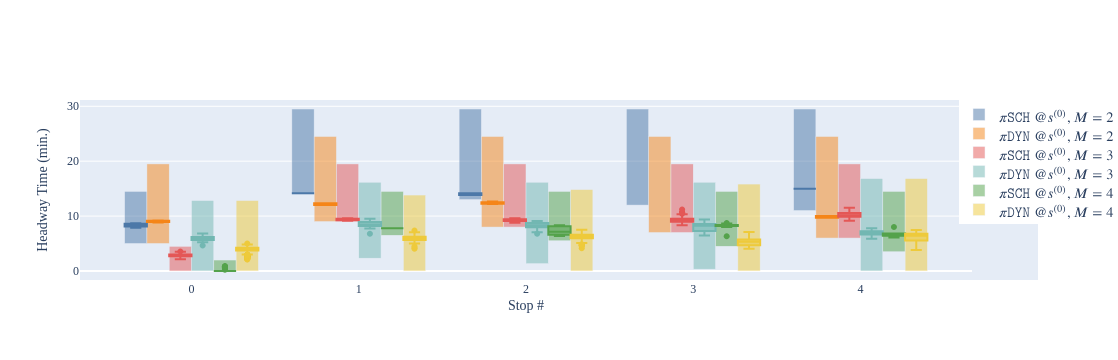

In [9]:
# Base route - no control
N_STOPS = 5
BASE_ROUTE = [
    {
        'tau': (4, 4.5),
        'delta': (0, 0.5),
        'policy': BolehPolicy,
        'policy_args': {},
    } for _ in range(N_STOPS)
]

# Scheduled terminal departure
SCHED_ROUTE = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE[0]['policy_args'] = {'time_delta': 10, 'offset': 0}

# Scheduled terminal departure
SCHED_ROUTE2 = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE2[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE2[0]['policy_args'] = {'time_delta': 15, 'offset': 0}

# Scheduled terminal departure
SCHED_ROUTE4 = copy.deepcopy(BASE_ROUTE)
SCHED_ROUTE4[0]['policy'] = LeakyBucketPolicy
SCHED_ROUTE4[0]['policy_args'] = {'time_delta': 7.5, 'offset': 0}

# Ratio Driven Route has one stop driven by ratio policy
RATIO_ROUTE = copy.deepcopy(BASE_ROUTE)
RATIO_ROUTE[0]['policy'] = RatioDrivenPolicy
RATIO_ROUTE[0]['policy_args'] = {'target_ratio': 1, 'activation_ratio': 1, 'max_holding': float('inf')}


routes = {
    r'$\pi\texttt{SCH}\;@s^{(0)}, M=2$': (SCHED_ROUTE2, [0, 15]),
    r'$\pi\texttt{DYN}\;@s^{(0)}, M=2$': (RATIO_ROUTE, [0, 15]),
    r'$\pi\texttt{SCH}\;@s^{(0)}, M=3$': (SCHED_ROUTE, [0, 10, 20]),
    r'$\pi\texttt{DYN}\;@s^{(0)}, M=3$': (RATIO_ROUTE, [0, 10, 20]), 
    r'$\pi\texttt{SCH}\;@s^{(0)}, M=4$': (SCHED_ROUTE4, [0, 7.5, 15, 22.5]),
    r'$\pi\texttt{DYN}\;@s^{(0)}, M=4$': (RATIO_ROUTE, [0, 7.5, 15, 22.5]), 
}
t_max=60 * 24 * 7
results = {}
for name, route in routes.items():
    print(f'Working on {name}...')
    wc_headway, bc_headway = wcht(route_factory(route[0]), route[1], t_max)
    wc_travel = []
    for i in range(len(route[0])):
        wc_travel.append([])
        for j in range(len(route[0])):
            wc_travel[i].append(wctt(route_factory(route[0]), route[1], wc_headway, i, j))
    prob_results = simulate(route_factory(route[0]), route[1], t_max, seed=0)
    results[name] = {
        'worst_case': {'headway': wc_headway, 'travel': wc_travel},
        'best_case': {'headway': bc_headway},
        'simulation': prob_results,
        'route': route[0]
    }

plot_headway(results)